# Regresión Lineal

La **Regresión Lineal** es uno de los modelos más básicos para problemas de regresión.  
Su objetivo es encontrar una relación lineal entre las variables de entrada y una variable objetivo continua.

La forma general del modelo es:

$
\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n
$

donde:

- \($x_i$\) son las variables de entrada
- \($w_i$\) son los coeficientes aprendidos por el modelo
- \($w_0$\) es el intercepto
- \($\hat{y}$\) es la predicción

Este modelo intenta minimizar el error entre los valores reales y las predicciones.  
Es especialmente útil cuando la relación entre variables es aproximadamente lineal.

In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Importando módulo propio
from utils.regression_functions import *

## Funciones auxiliares

In [3]:
def evaluate_regression_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    return metrics

In [4]:
def train_and_evaluate_linear_regression(
    data_file,
    test_size=0.2,
    random_seed=42,
    plot_limit=200,
    sort_by_real=True,
    plot_feature=None,
    plot_3d=False
):
    data_path = Path("../data/mocked_data") / data_file
    df = pd.read_csv(data_path)

    X = df.drop(columns=["y"])
    y = df["y"]

    print("=" * 80)
    print(f"Dataset loaded: {data_file}")
    print(f"Shape: {df.shape}")
    print(f"Input features: {list(X.columns)}")
    print()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=True,
        random_state=random_seed
    )

    print("Training set:", X_train.shape)
    print("Test set:", X_test.shape)
    print()

    model = Pipeline([
        # ("scaler", StandardScaler()),
        ("linear_regression", LinearRegression())
    ])

    model.fit(X_train, y_train)

    print("Model trained successfully.")
    print()

    y_pred = model.predict(X_test)

    metrics = evaluate_regression_model(y_test, y_pred)

    print("Regression Metrics")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    print()

    linear_model = model.named_steps["linear_regression"]

    print("Model Parameters")
    print("Intercept:", linear_model.intercept_)
    print("Coefficients:", linear_model.coef_)
    print()

    if X_test.shape[1] == 1:
        plot_real_vs_pred(
            y_test=y_test,
            y_pred=y_pred,
            sample_limit=plot_limit,
            sort_by_real=False,
            title=f"Real vs Predicción — {data_file}",
            xlabel=X_test.columns[0],
            ylabel="y",
            x_values=X_test
        )
    else:
        if plot_feature is None:
            plot_feature = X_test.columns[0]

        print(f"Multi-feature dataset detected. Plotting against: {plot_feature}")
        print()

        plot_real_vs_pred(
            y_test=y_test,
            y_pred=y_pred,
            sample_limit=plot_limit,
            sort_by_real=False,
            title=f"Real vs Predicción — {data_file} ({plot_feature})",
            xlabel=plot_feature,
            ylabel="y",
            x_values=X_test,
            x_col=plot_feature
        )

        if plot_3d and X_test.shape[1] == 2:
            from mpl_toolkits.mplot3d import Axes3D

            x1_name = X_test.columns[0]
            x2_name = X_test.columns[1]

            plot_df = X_test.copy()
            plot_df["y_test"] = np.asarray(y_test)
            plot_df["y_pred"] = np.asarray(y_pred)

            if plot_limit is not None:
                plot_df = plot_df.iloc[:plot_limit].copy()

            fig = plt.figure(figsize=(10, 7))
            ax = fig.add_subplot(111, projection="3d")

            ax.scatter(
                plot_df[x1_name],
                plot_df[x2_name],
                plot_df["y_test"],
                label="Real",
                alpha=0.7
            )

            ax.scatter(
                plot_df[x1_name],
                plot_df[x2_name],
                plot_df["y_pred"],
                label="Predicción",
                alpha=0.7
            )

            ax.set_title(f"Real vs Predicción en 3D — {data_file}")
            ax.set_xlabel(x1_name)
            ax.set_ylabel(x2_name)
            ax.set_zlabel("y")
            ax.legend()
            plt.tight_layout()
            plt.show()

    results_df = pd.DataFrame({
        "y_test": np.asarray(y_test),
        "y_pred": np.asarray(y_pred)
    })

    return {
        "data_file": data_file,
        "df": df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "model": model,
        "metrics": metrics,
        "results_df": results_df
    }

## Datasets a evaluar

In [5]:
DATASETS = [
    "regression_linear_1d.csv",
    "regression_polynomial_1d.csv",
    "regression_sinusoidal_1d.csv",
    "regression_piecewise_1d.csv",
    "regression_interaction_2d.csv"
]

DATASETS

['regression_linear_1d.csv',
 'regression_polynomial_1d.csv',
 'regression_sinusoidal_1d.csv',
 'regression_piecewise_1d.csv',
 'regression_interaction_2d.csv']

## Entrenamiento y evaluación

Dataset loaded: regression_linear_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 0.6457
MSE: 0.6277
RMSE: 0.7923
R2: 0.9970

Model Parameters
Intercept: 1.0245831868081425
Coefficients: [2.50057182]



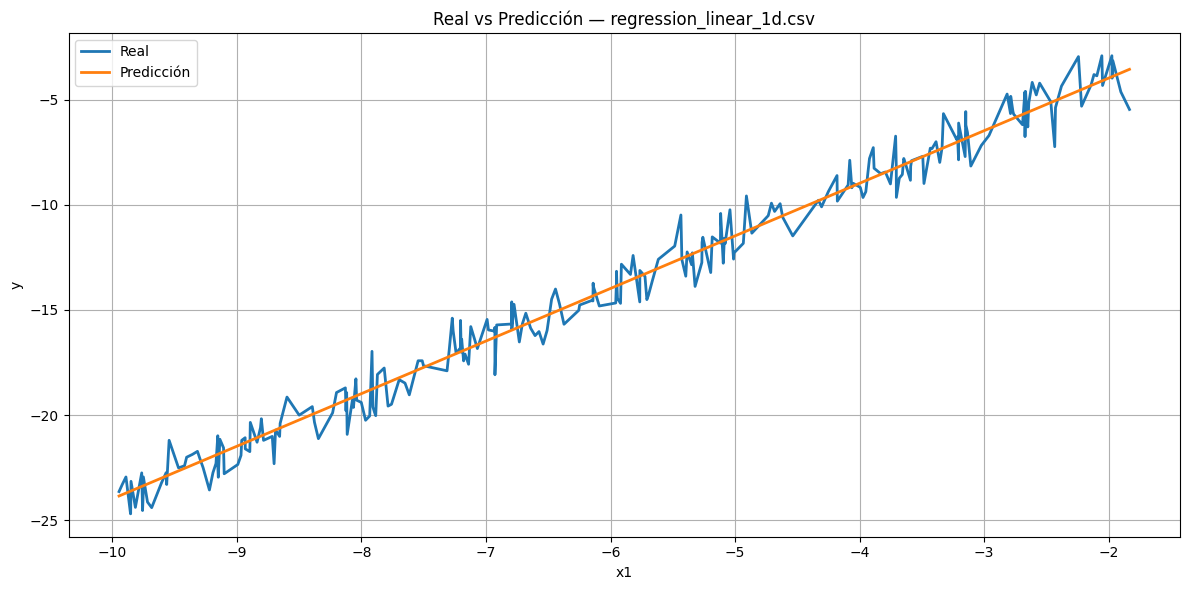

Dataset loaded: regression_polynomial_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 6.9417
MSE: 76.1425
RMSE: 8.7260
R2: 0.8149

Model Parameters
Intercept: -4.624414882140369
Coefficients: [6.89900731]



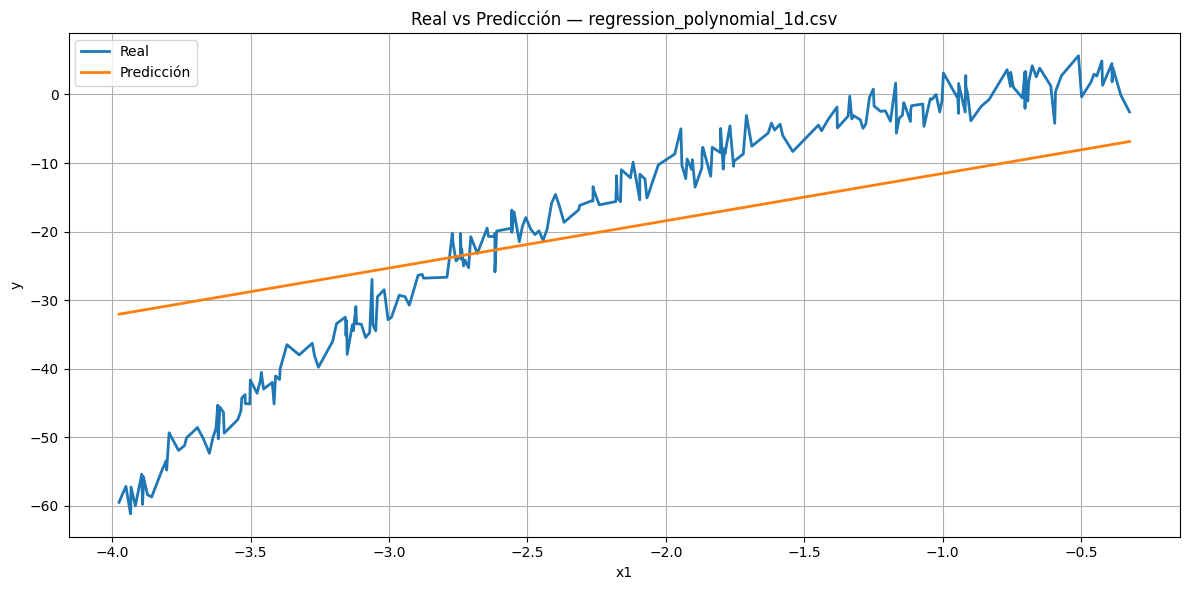

Dataset loaded: regression_sinusoidal_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 1.7812
MSE: 4.1925
RMSE: 2.0476
R2: 0.5125

Model Parameters
Intercept: -0.024827283108273136
Coefficients: [0.37777754]



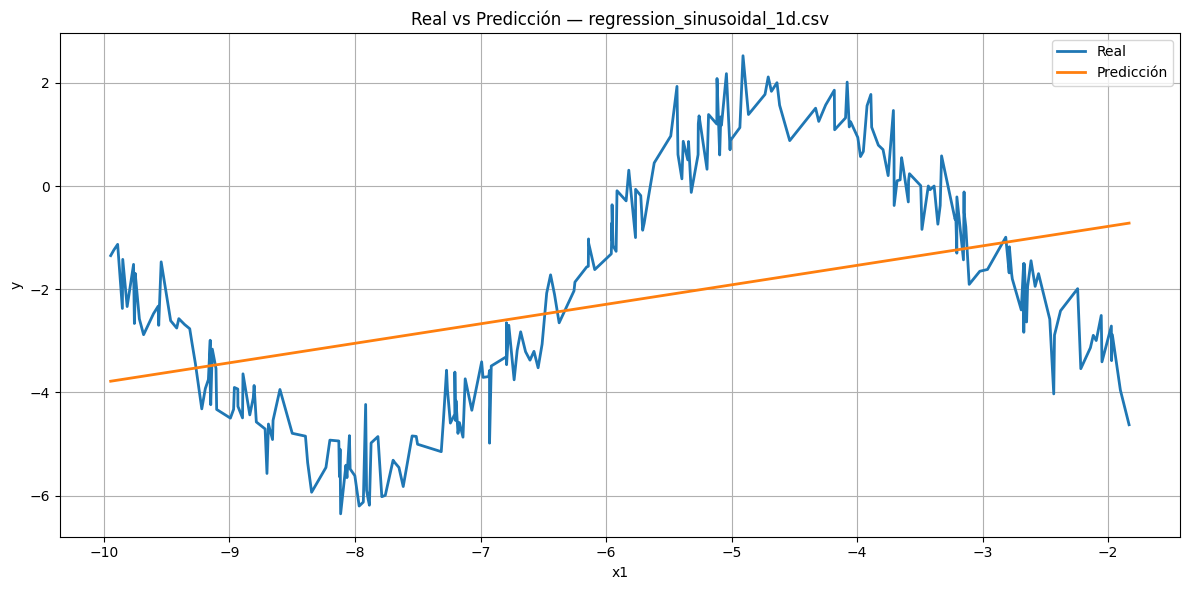

Dataset loaded: regression_piecewise_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 2.7570
MSE: 10.2255
RMSE: 3.1977
R2: 0.0435

Model Parameters
Intercept: -3.2715183226887854
Coefficients: [-0.27228429]



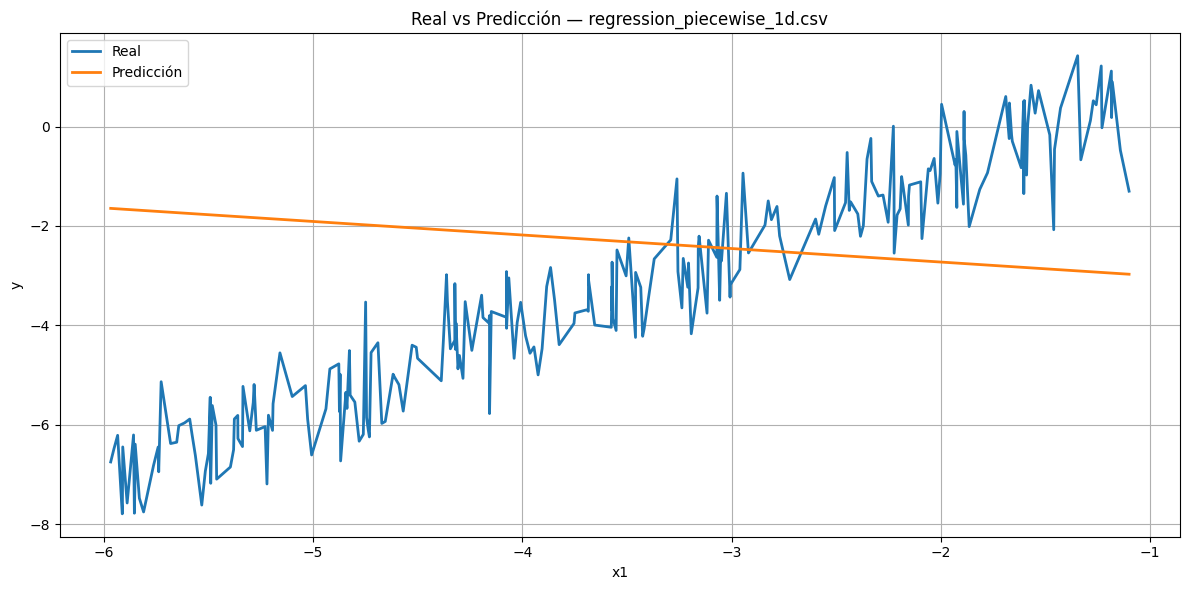

Dataset loaded: regression_interaction_2d.csv
Shape: (5000, 3)
Input features: ['x1', 'x2']

Training set: (4000, 2)
Test set: (1000, 2)

Model trained successfully.

Regression Metrics
MAE: 6.1783
MSE: 66.6241
RMSE: 8.1624
R2: 0.1227

Model Parameters
Intercept: 0.12601884370533042
Coefficients: [1.21342162 0.79506102]

Multi-feature dataset detected. Plotting against: x1



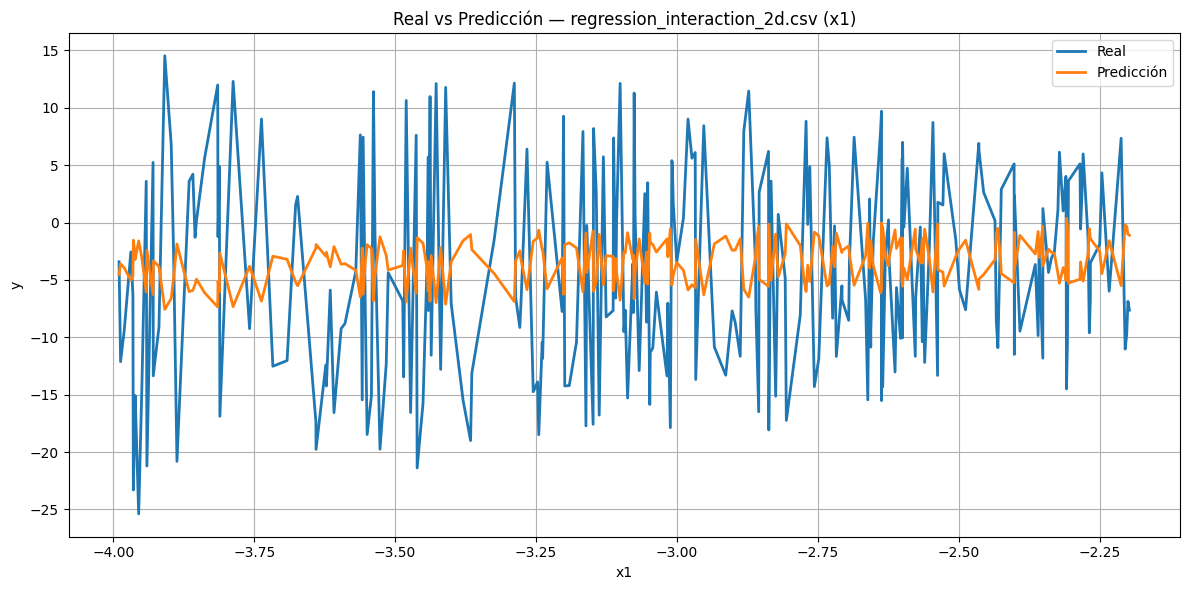

In [6]:
all_results = {}

for data_file in DATASETS:
    result = train_and_evaluate_linear_regression(
        data_file=data_file,
        test_size=0.2,
        random_seed=42,
        plot_limit=250,
        sort_by_real=True
    )
    all_results[data_file] = result

## Resumen de métricas

In [7]:
metrics_summary = pd.DataFrame(
    [
        {
            "dataset": data_file,
            "MAE": result["metrics"]["MAE"],
            "MSE": result["metrics"]["MSE"],
            "RMSE": result["metrics"]["RMSE"],
            "R2": result["metrics"]["R2"]
        }
        for data_file, result in all_results.items()
    ]
)

metrics_summary.sort_values(by="RMSE")

,dataset,MAE,MSE,RMSE,R2
0,regression_linear_1d.csv,0.645749,0.627734,0.792297,0.996955
2,regression_sinusoidal_1d.csv,1.781172,4.192502,2.047560,0.512545
3,regression_piecewise_1d.csv,2.756997,10.225528,3.197738,0.043498
4,regression_interaction_2d.csv,6.178293,66.624102,8.162359,0.122656
1,regression_polynomial_1d.csv,6.941713,76.142488,8.725966,0.814899


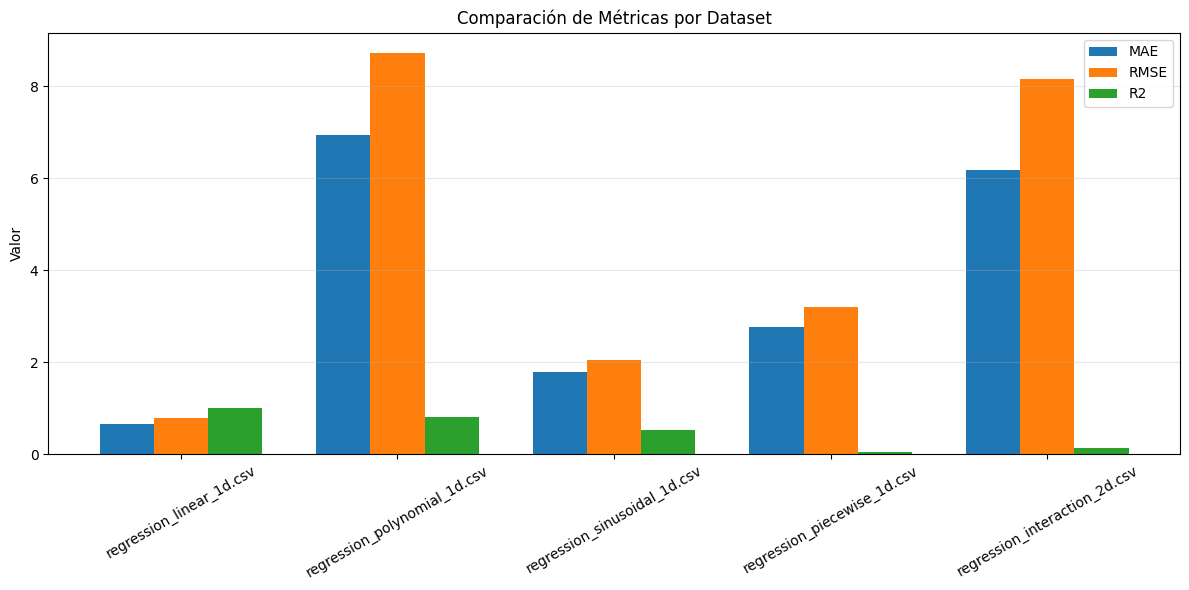

In [8]:
# Visualización de métricas por dataset

import matplotlib.pyplot as plt
import numpy as np

metrics = ["MAE", "RMSE", "R2"]
datasets = metrics_summary["dataset"]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, metrics_summary[metric], width=width, label=metric)

plt.xticks(x + width, datasets, rotation=30)
plt.ylabel("Valor")
plt.title("Comparación de Métricas por Dataset")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()